In [4]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo




In [5]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [10]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


# Test

[INFO] Generating GRB population and saving to output/GRBafterglows/test_pop_1yr_nearby.pkl
Simulated 974 GRB events using rate_density = 1.0e-04


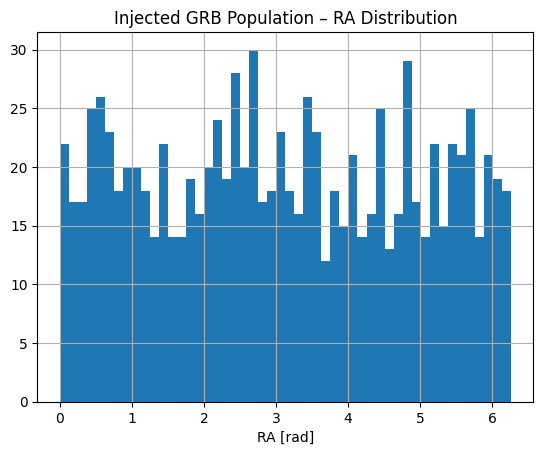

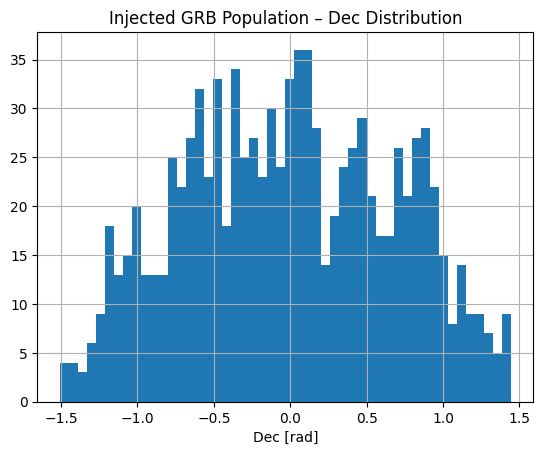

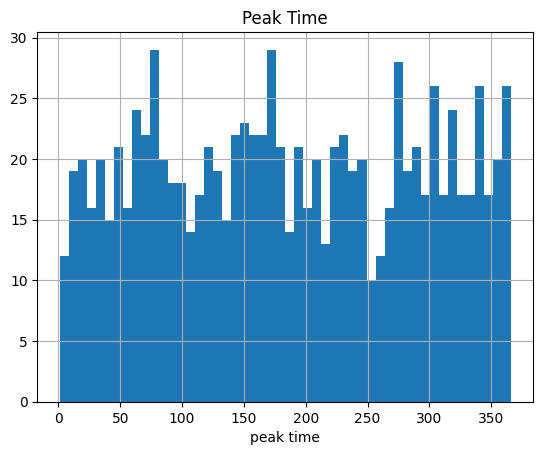

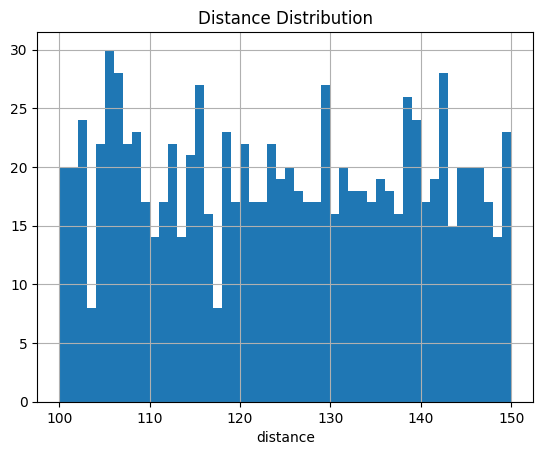

[DEBUG 7]: Do you see me
[DEBUG] coords.dec[:5]: [ 55.10793643 -33.51005607 -18.20995686   7.18075578   7.78271439] deg
[DEBUG] coords.dec.unit: deg


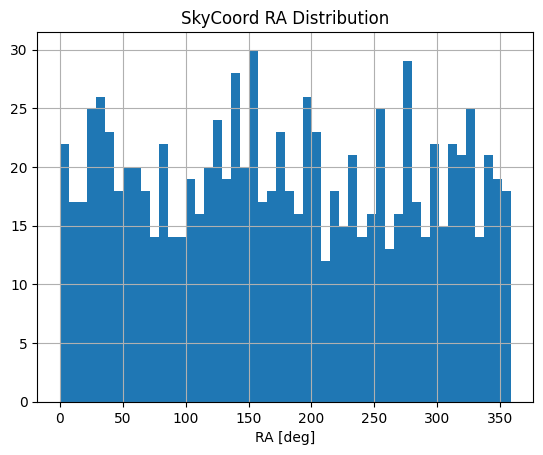

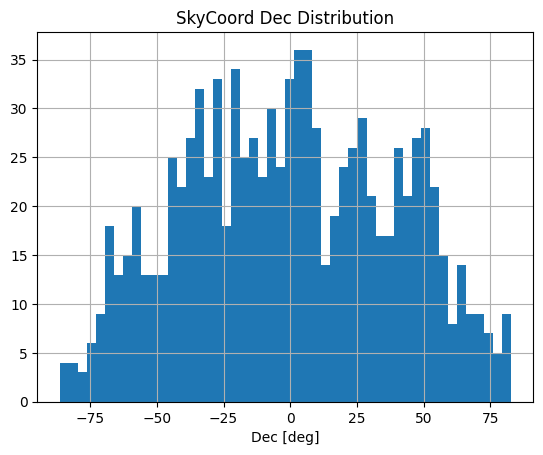

Saved GRB population to output/GRBafterglows/test_pop_1yr_nearby.pkl


In [63]:
# For generating a fast test population and metric evaluation
t_start = 1
t_end = 366  # one year
d_min = 100  # Mpc
d_max = 150  # Mpc
rate_density = 1e-4  # inflate rate so we get more events
generate_new = True
make_debug_plots = True

# a pop file name that makes it clear this is a test
os.makedirs("output/GRBafterglows", exist_ok=True)
pop_file = "output/GRBafterglows/test_pop_1yr_nearby.pkl"

# Load or generate the test population
slicer = metric.load_or_generate_population(
    t_start=t_start, t_end=t_end,
    d_min=d_min, d_max=d_max,
    rate_density=rate_density,  # artificially high
    generate_new=generate_new,
    pop_file=pop_file,
    make_debug_plots=make_debug_plots
)




--- Running baseline_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'numpy.ndarray'> | length: 778
mag_obs         | type: <class 'numpy.ndarray'> | length: 778
snr_obs         | type: <class 'numpy.ndarray'> | length: 778
filter          | type: <class 'numpy.ndarray'> | length: 778
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid             | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 632
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 121.94392198760262
peak_mjd        | type: <class 'numpy.float64'> | value: 63906.25227580979
peak_mag        | type: <class 'numpy.float64'> | value: 134.45847038766038
ebv      

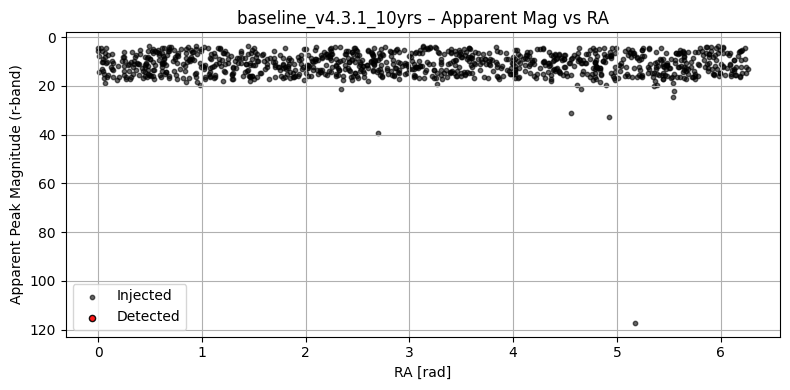

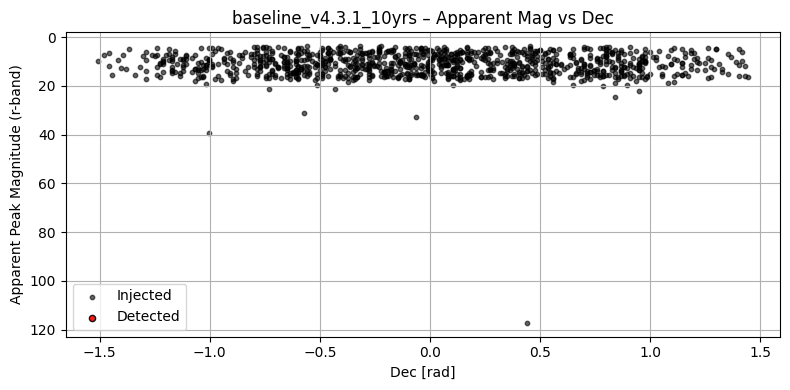

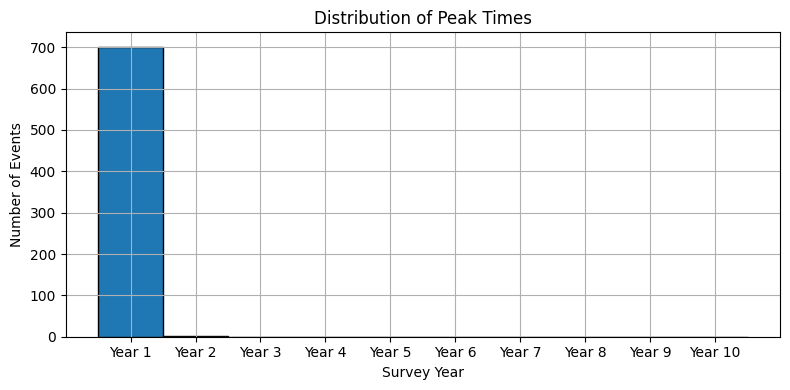

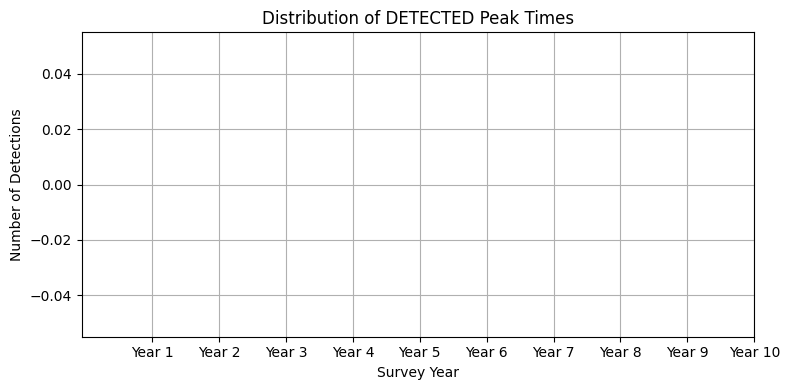

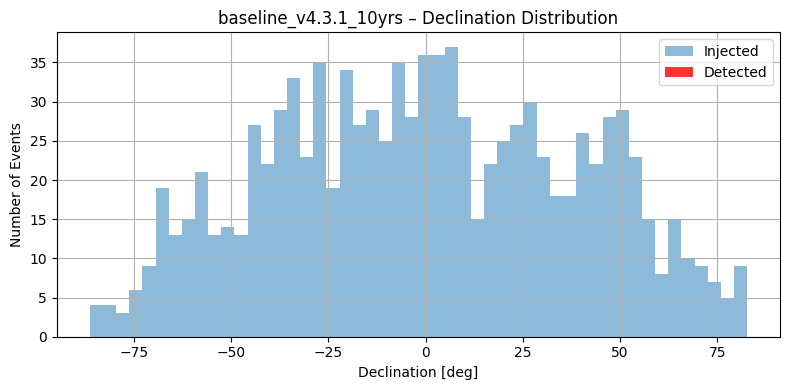


--- Running four_roll_v4.3.1_10yrs ---

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'numpy.ndarray'> | length: 754
mag_obs         | type: <class 'numpy.ndarray'> | length: 754
snr_obs         | type: <class 'numpy.ndarray'> | length: 754
filter          | type: <class 'numpy.ndarray'> | length: 754
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid             | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 632
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 121.94392198760262
peak_mjd        | type: <class 'numpy.float64'> | value: 64347.14632091699
peak_mag        | type: <class 'numpy.float64'> | value: 134.45847038766038
ebv     

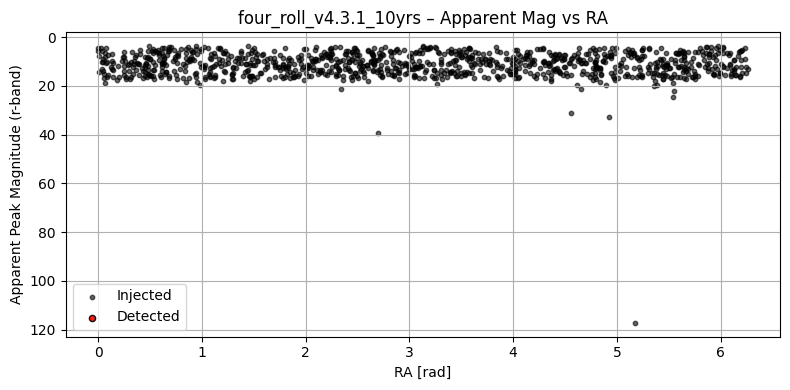

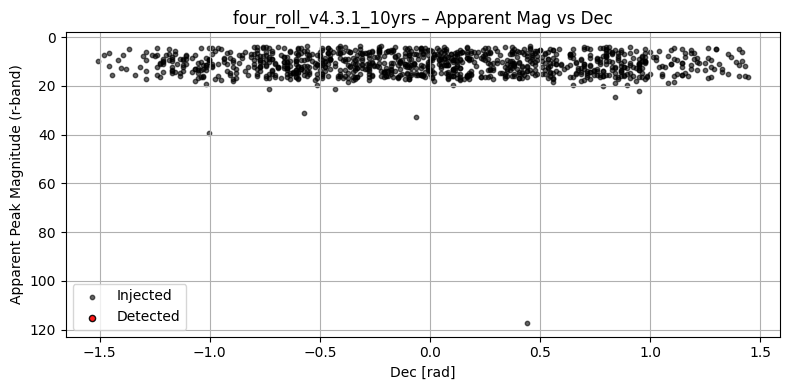

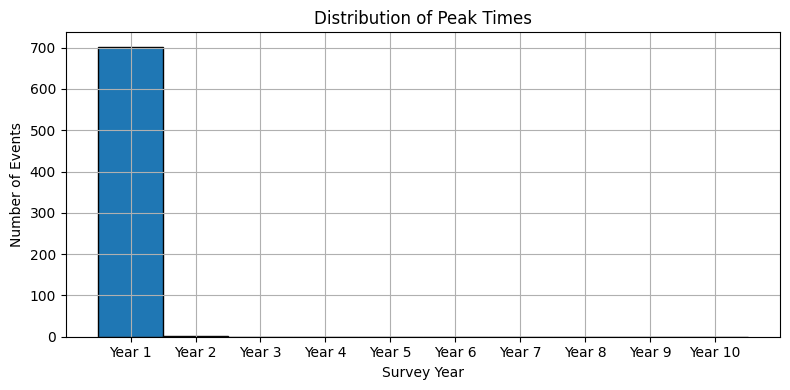

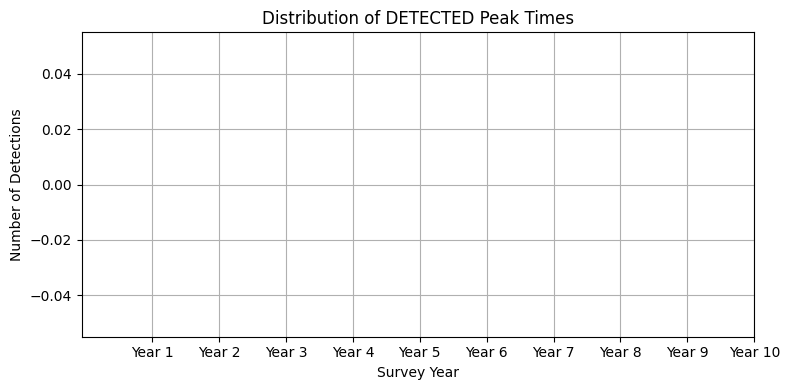

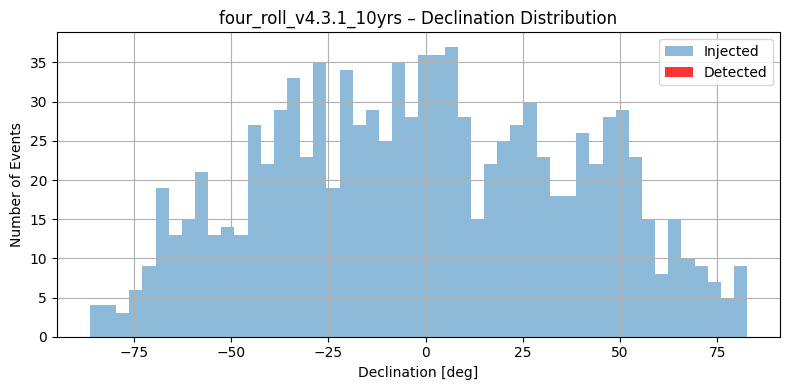

In [62]:

# just test detection for now
detected_df = shared_utils.run_detect(
    metric=metric,
    slicer=slicer,
    cadences=['baseline_v4.3.1_10yrs', 'four_roll_v4.3.1_10yrs'],
    shared_lc_model=shared_lc_model,
    db_dir=db_dir,
    storage_dir=storage_dir,
    ignore_triples=False,
    debug=True,
    plot=True,
    clean_temp=False
)

